In [1]:
import pandas as pd

df = pd.read_csv("pone.0246039.s001.csv")

df.head()

,samples,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V3563,V3564,V3565,V3566,V3567,V3568,V3569,V3570,V3571,Response
0,1,-0.788350,-0.756913,-1.414095,-0.718028,0.473398,3.113805,2.749407,2.628862,3.146849,...,-0.660664,-0.277515,-0.190609,1.096830,0.069212,-0.178846,0.468823,-0.331179,-0.825661,normal
1,2,-1.335163,-1.335163,-1.335163,-1.205542,-0.055226,0.251215,-1.213103,1.040300,3.097184,...,-0.756412,-0.670722,-0.603962,0.263903,0.520380,-0.037259,0.461020,-0.390380,-1.335163,normal
2,3,-1.423499,-1.423499,-1.389461,-0.069438,0.911507,2.080529,1.603549,1.702697,2.980989,...,-0.487601,-0.091597,0.289707,0.328599,0.732303,-0.973264,0.686988,0.355827,-0.708238,normal
3,4,-0.941616,-1.362703,-1.362703,-0.959263,-0.052647,2.210509,1.520901,1.625528,3.244964,...,-1.135454,-0.230745,-0.330132,0.483504,0.590966,-0.852819,0.327239,-0.874228,-1.149951,normal
4,5,-1.373415,-0.527130,-1.373415,-1.191340,0.068572,0.963808,1.654828,-0.319909,3.193077,...,-1.373415,-0.948803,-0.845447,0.306028,0.339066,0.107542,-0.534426,-0.325722,-1.373415,normal


In [2]:
df.shape

(72, 3573)

In [3]:
df.columns

Index(['samples', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9',
       ...
       'V3563', 'V3564', 'V3565', 'V3566', 'V3567', 'V3568', 'V3569', 'V3570',
       'V3571', 'Response'],
      dtype='object', length=3573)

In [4]:
X = df.drop(['samples','Response'], axis=1)
y = df['Response']

print(X.shape)
print(y.shape)

(72, 3571)
(72,)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(72, 3571)


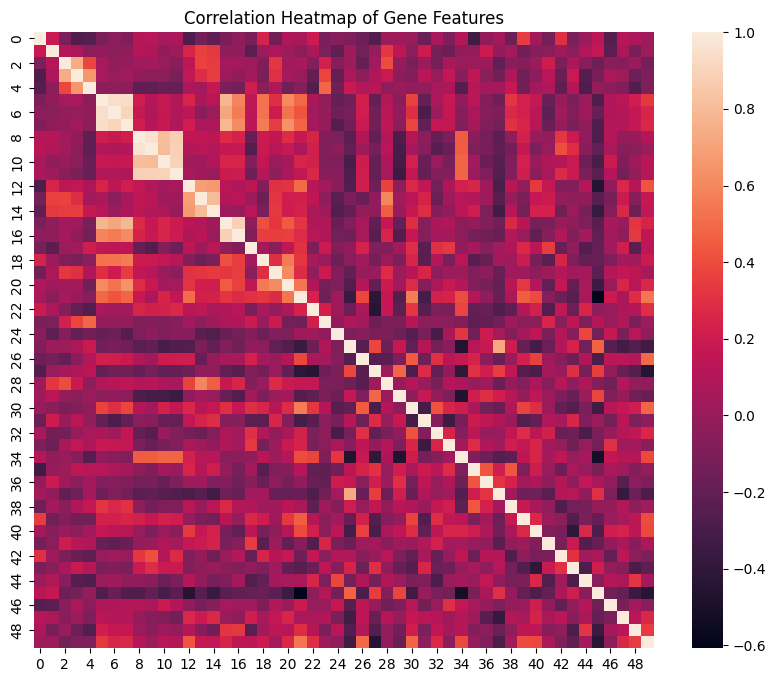

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

corr = pd.DataFrame(X_scaled).iloc[:, :50].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr)

plt.title("Correlation Heatmap of Gene Features")

plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, pred_svm))

SVM Accuracy: 1.0


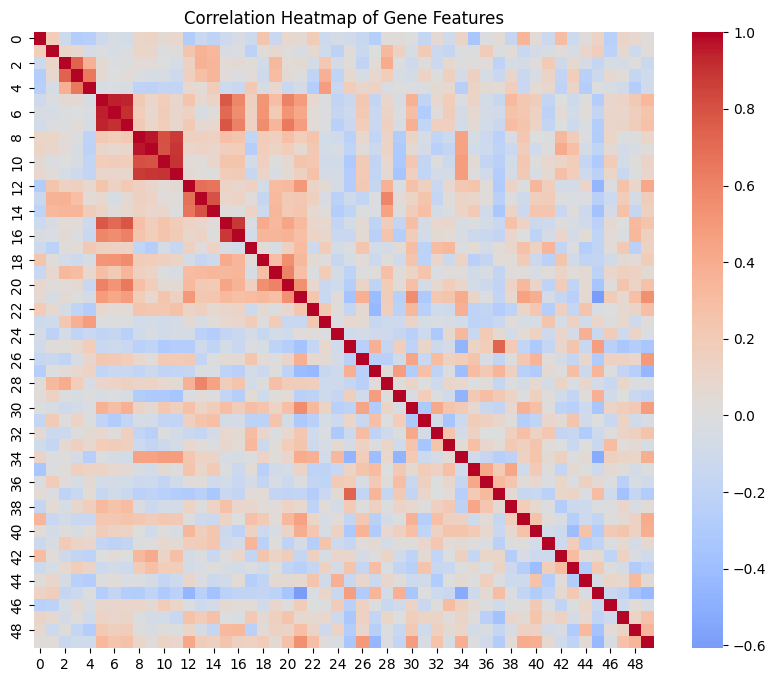

In [9]:
corr = pd.DataFrame(X_scaled).iloc[:, :50].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap of Gene Features")

plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, pred_svm))

SVM Accuracy: 1.0


In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))

Logistic Regression Accuracy: 1.0


In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, pred_knn))

KNN Accuracy: 1.0


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [15]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, pred_svm))

SVM Accuracy: 0.9545454545454546


In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(svm, X_scaled, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [1.         1.         1.         1.         0.92857143]
Average Accuracy: 0.9857142857142858


In [17]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_reduced = selector.fit_transform(X_scaled)

print(X_reduced.shape)

(72, 3571)


In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=30)

X_pca = pca.fit_transform(X_reduced)

print(X_pca.shape)

(72, 30)


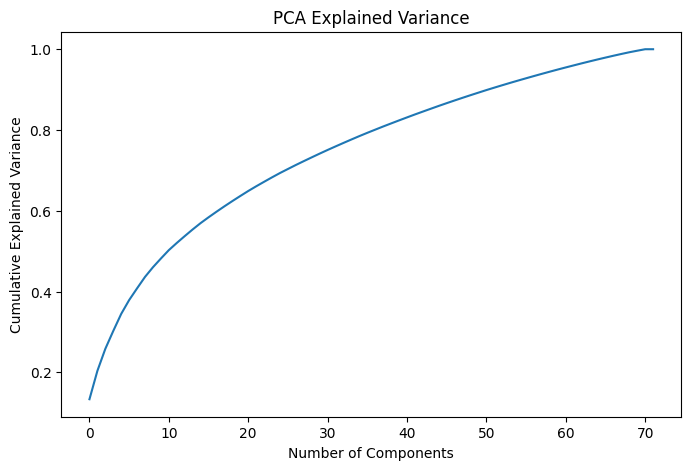

In [21]:
pca_full = PCA()

pca_full.fit(X_scaled)

plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca_full.explained_variance_ratio_))

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.show()

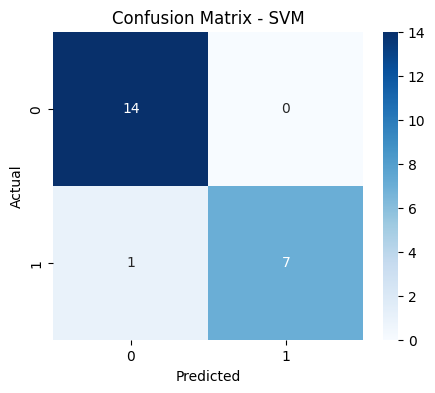

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_svm)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, cmap="Blues")

plt.title("Confusion Matrix - SVM")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_svm))

              precision    recall  f1-score   support

      normal       0.93      1.00      0.97        14
       tumar       1.00      0.88      0.93         8

    accuracy                           0.95        22
   macro avg       0.97      0.94      0.95        22
weighted avg       0.96      0.95      0.95        22



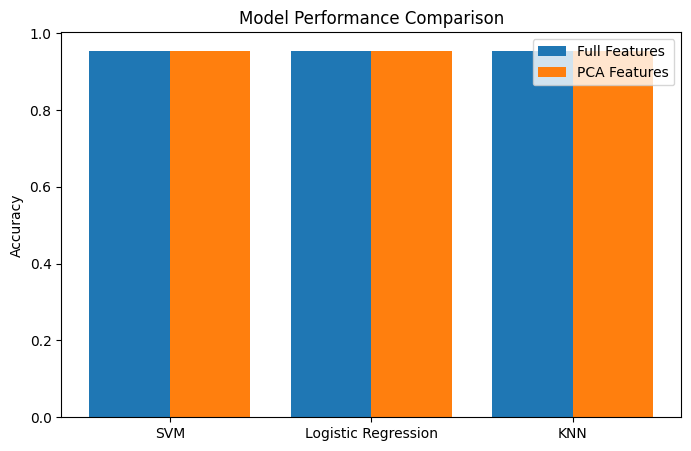

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# --- Calculate accuracies for Full Features (X_scaled) ---
# X_train, X_test, y_train, y_test are already defined from the last train_test_split using X_scaled

# SVM (Full Features)
svm_full = SVC(kernel='linear') # Using the same kernel as in B1ynjANXoOtY
svm_full.fit(X_train, y_train)
pred_svm_full = svm_full.predict(X_test)
svm_acc = accuracy_score(y_test, pred_svm_full)

# Logistic Regression (Full Features)
lr_full = LogisticRegression(max_iter=5000) # Using the same max_iter as in q8y_3lNan_la
lr_full.fit(X_train, y_train)
pred_lr_full = lr_full.predict(X_test)
lr_acc = accuracy_score(y_test, pred_lr_full)

# KNN (Full Features)
knn_full = KNeighborsClassifier(n_neighbors=5) # Using the same n_neighbors as in dlupVV1moBK1
knn_full.fit(X_train, y_train)
pred_knn_full = knn_full.predict(X_test)
knn_acc = accuracy_score(y_test, pred_knn_full)

# --- Calculate accuracies for PCA Features (X_pca) ---
# Perform train_test_split on X_pca to get training and testing sets
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y # Consistent split parameters
)

# SVM (PCA Features)
svm_pca = SVC(kernel='linear')
svm_pca.fit(X_pca_train, y_pca_train)
pred_svm_pca = svm_pca.predict(X_pca_test)
svm_pca_acc = accuracy_score(y_pca_test, pred_svm_pca)

# Logistic Regression (PCA Features)
lr_pca = LogisticRegression(max_iter=5000)
lr_pca.fit(X_pca_train, y_pca_train)
pred_lr_pca = lr_pca.predict(X_pca_test)
lr_pca_acc = accuracy_score(y_pca_test, pred_lr_pca)

# KNN (PCA Features)
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_pca_train, y_pca_train)
pred_knn_pca = knn_pca.predict(X_pca_test)
knn_pca_acc = accuracy_score(y_pca_test, pred_knn_pca)

# --- Original plotting code ---
models = ["SVM","Logistic Regression","KNN"]

full_scores = [svm_acc, lr_acc, knn_acc]
pca_scores = [svm_pca_acc, lr_pca_acc, knn_pca_acc]

x = np.arange(len(models))

plt.figure(figsize=(8,5))

plt.bar(x-0.2, full_scores, 0.4, label="Full Features")

plt.bar(x+0.2, pca_scores, 0.4, label="PCA Features")

plt.xticks(x, models)

plt.ylabel("Accuracy")

plt.title("Model Performance Comparison")

plt.legend()

plt.show()

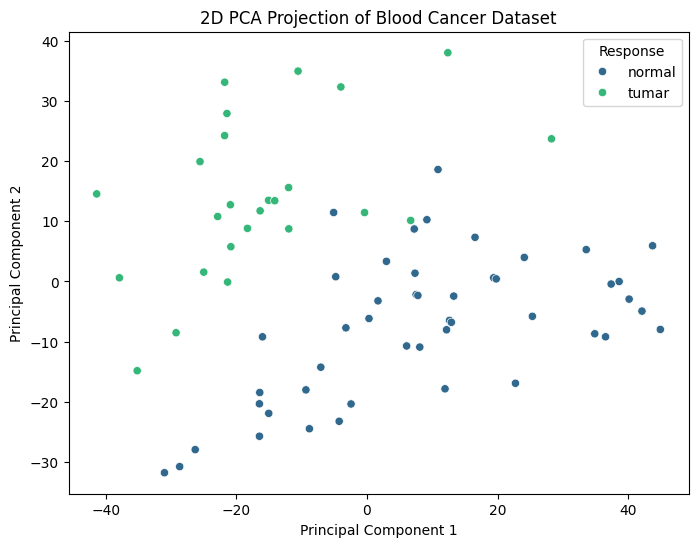

In [27]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_2d[:,0],
    y=X_2d[:,1],
    hue=y,
    palette="viridis"
)

plt.title("2D PCA Projection of Blood Cancer Dataset")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [28]:
svm2 = SVC(kernel='linear')

svm2.fit(X_2d, y)

SVC(kernel='linear')

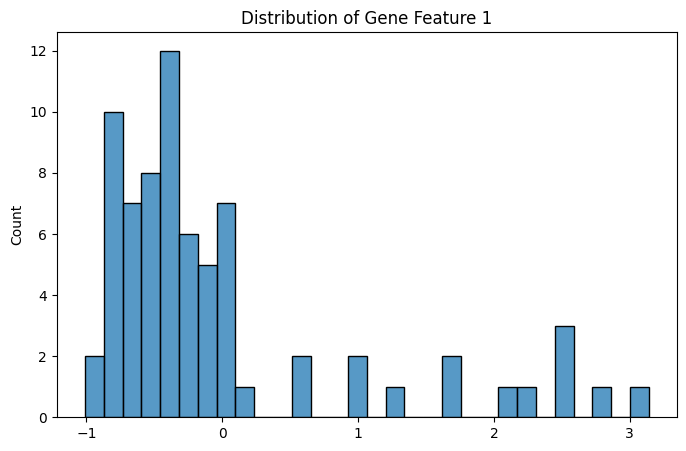

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(X_scaled[:,0], bins=30)

plt.title("Distribution of Gene Feature 1")

plt.show()

In [30]:
variance = pca_full.explained_variance_ratio_

print("Variance captured by first 10 components:")

print(variance[:10])

Variance captured by first 10 components:
[0.13324168 0.0702542  0.05461767 0.04424928 0.04224747 0.03421361
 0.02908299 0.02830313 0.02394748 0.02152199]
